In [73]:
# Instalação de todas as dependências
!pip install scikit-learn pandas numpy optuna xgboost scipy shap matplotlib seaborn s3fs pyarrow

In [74]:
# ======================================
# IMPORTANDO BIBLIOTECAS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualização da árvore
from sklearn.tree import plot_tree

# Normalização
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#Métricas de classificação
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#Feature selection
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.feature_selection import RFECV

#Validação
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

#Validação cruzada
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import optuna
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint, loguniform

#SHAP
import shap



# **Treino do modelo e métricas de validação**

In [75]:
# ======================================
# CONECTANDO NA GOLD (BASE DE DADOS)
# ======================================

# VARIAVEIS
s3_path_comparativo_metas_resultados = "s3://fiap-datalake-tech-public/gold/comparativo_metas_resultados/"


#ACESSO
dados = pd.read_parquet(
    s3_path_comparativo_metas_resultados,
    engine="pyarrow",
    storage_options={"anon": True}
)

dados.head(n=5)


,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3


In [76]:
pib_renda = pd.read_csv('pib_renda_gold.csv')

#Merge de IDHM
dados_mais_pib_renda = dados.merge(
    pib_renda[['id_municipio', 'pib_per_capita_R$','renda_media_per_capita_R$','densidade_demografica']],
    on='id_municipio',
    how='left'
)

dados_mais_pib_renda.head()

,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
1,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
2,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
3,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874
4,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874


In [77]:
# ======================================
# IMPUTER TRANSFORMER
# ======================================

#Colunas de meta_ano e desvio_ano não possuem valores para 2023 porque foi o primeiro ano da pesquisa (sem meta para aquele ano específico porque começou naquele momento)

#Não escolhemos SimpleImputer ou KNNImputer porque preencher o desvio ausente com a média dos desvios de quem tinha meta vai inventar um desvio para quem não deveria ter nenhum, e no caso do KNN, ele tentará adivinhar o desvio com base em outros clientes/registros parecidos, violando a regra de negócio de que "sem meta = sem desvio".

# # 1. Preenche o desvio com 0 quando não houver meta
# dados['desvio_meta'] = dados['desvio_meta'].fillna(0)

# 2. Preenche a meta_ano com um valor sentinela (ex: -1) para não quebrar a regressão
# dados['meta_ano'] = dados['meta_ano'].fillna(-1)

imputer_num = SimpleImputer(strategy='median')

# Aplica apenas nas colunas numéricas
dados_nulos = ['renda_media_per_capita_R$','pib_per_capita_R$','densidade_demografica']
dados_mais_pib_renda[dados_nulos] = imputer_num.fit_transform(dados_mais_pib_renda[dados_nulos])

dados_mais_pib_renda.head()


,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
1,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
2,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
3,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874
4,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874


In [78]:
# ======================================
# FEATURE ENGENEERING
# ======================================
#Foi feita na Gold porque na Silver só tínhamos a meta do municipio e a taxa real, na Gold calculamos o desvio entre a meta e realidade.

# ======================================
# FEATURE EXTRACTION
# ======================================

#Para chegarmos no Status Meta (com as classes "atingiu" ou "não atingiu") utilizamos o desvio, se era >=0 o municipio atingiu, se não, não atingiu a meta.
# O feature extraction ajudou a não ter no modelo duas features que não agregariam (meta_ano e desvio_ano) e que poderiam gerar associações espúrias e aumentar a dimensionalidade.


In [79]:
# ======================================
# DEFININDO X e y e divisão treino e teste
# ======================================

#Definição do y
y_bruto = dados_mais_pib_renda['status_meta']

#Definição do X
X_bruto = dados_mais_pib_renda[['id_municipio', 'total_avaliados', 'ano', 'taxa_alfabetizacao_real','sigla_uf','renda_media_per_capita_R$','pib_per_capita_R$','densidade_demografica']]

#Feature encoding do X
  # Aplicar One-Hot Encoding en sigla_uf (Estado)
X = pd.get_dummies(X_bruto, columns=['sigla_uf'], drop_first=True, dtype=int)

# Divisão Treino e Teste
X_train, X_test, y_train_bruto, y_test_bruto = train_test_split(
    X,
    y_bruto,
    test_size=0.2,
    random_state=42,
    stratify=y_bruto
)

#Feature encoding do y
le_y = LabelEncoder()
  # O fit é feito APENAS no treino
y_train = le_y.fit_transform(y_train_bruto)
  # O teste é apenas transformado (usando o mapeamento aprendido no treino)
y_test = le_y.transform(y_test_bruto)

# Escalonamento do X (apenas das features que passaram pelo variance threshold)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Utilizamos o StandardScale (desvio padrão) porque é indicado para Regressão Logística, já que não temos tantos outliers no conjunto de dados para justificar o uso do Robust Scaling

# ======================================
# FEATURE SELECTION: SELECT KBEST
# ======================================

# Mutual Information (escolhida porque é mais versátil, permitindo qualquer feature categórica ou não. Apesar do dataset não ser grande (não possui milhares de observações), a seleção de features vai nos ajudar na interpretabilidade)
selector = SelectKBest(mutual_info_classif, k=15)

# Fit e transform no conjunto de treino escalonado
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

# Apenas transform no conjunto de teste
X_test_selected = selector.transform(X_test_scaled)

# Verificar quais features foram selecionadas
selected_names = X.columns[selector.get_support()]
print('Features selecionadas (Mutual Info):', selected_names.tolist())

print('Treino:', X_train_selected.shape)
print('Teste:', X_test_selected.shape)


Features selecionadas (Mutual Info): ['id_municipio', 'total_avaliados', 'ano', 'taxa_alfabetizacao_real', 'renda_media_per_capita_R$', 'pib_per_capita_R$', 'densidade_demografica', 'sigla_uf_CE', 'sigla_uf_DF', 'sigla_uf_MG', 'sigla_uf_PA', 'sigla_uf_RO', 'sigla_uf_RR', 'sigla_uf_RS', 'sigla_uf_SP']
Treino: (37094, 15)
Teste: (9274, 15)


Chegamos a utilizar o wrapper RFECV que encontra o ponto ótimo via validação cruzada, ele escolheu 27 features invés de 10 com selectkbest, teve uma ótima acurácia também: 0.8492, porém, demorou muito mais do que o selectkbest. Ou seja, tem um custo computacional maior.

In [80]:
# # =============================================================================
# # TREINAMENTO COM REGRESSÃO LOGÍSTICA (OTIMIZADO COM RANDOMIZED SEARCH CV)
# # =============================================================================
# 1. Definir o espaço de busca com distribuições contínuas
param_dist = {
    'C': loguniform(0.01, 1000),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000]
}

# 2. Instanciar a Regressão Logística
modelo = LogisticRegression(random_state=42)

# 3. Instanciar o RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 4. Executar a busca nos dados normalizados
random_search.fit(X_train_selected, y_train)

# 5. Exibir os resultados
print(f"Melhor score (Validação Cruzada): {random_search.best_score_:.4f}")
print("Melhores Hiperparâmetros:", random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor score (Validação Cruzada): 0.8360
Melhores Hiperparâmetros: {'C': np.float64(79.15074397656205), 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}


Usamos regressão logística porque inicialmente pensamos na possibilidade de usar probabilidade (qual a probabilidade de que esse municipio atinja a meta em 2026, 2027, 2028, 2029 e 2030?), de forma que a explicabilidade fosse mais facilitada.

Como nosso dataset é pequeno, e com pouca dimensionalidade, optamos pro um modelo que utiliza poucos recursos computacionais.

Além disso, optamos por Randomized Search CV por ter um custo mais controlado, já que o Grid Search demorou muito mais para processar e seu score teve um resultado de otimização quase irrosório.

Acurácia Geral:         0.8322
Precisão (Weighted):    0.8367
Recall (Weighted):      0.8322
F1-Score (Weighted):    0.8325

--- Relatório Completo por Classe ---
              precision    recall  f1-score   support

           0       0.68      0.63      0.66      2193
           1       0.79      0.88      0.83      3897
           2       1.00      0.91      0.95      3184

    accuracy                           0.83      9274
   macro avg       0.82      0.81      0.81      9274
weighted avg       0.84      0.83      0.83      9274



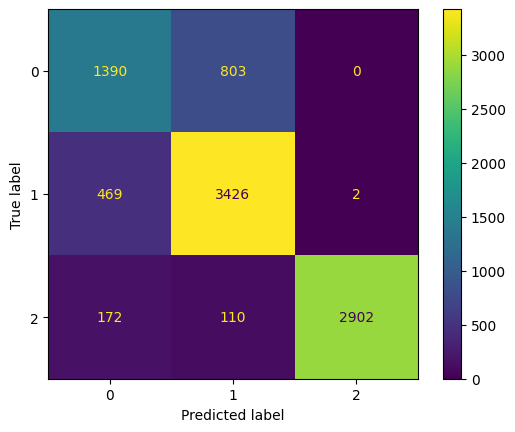

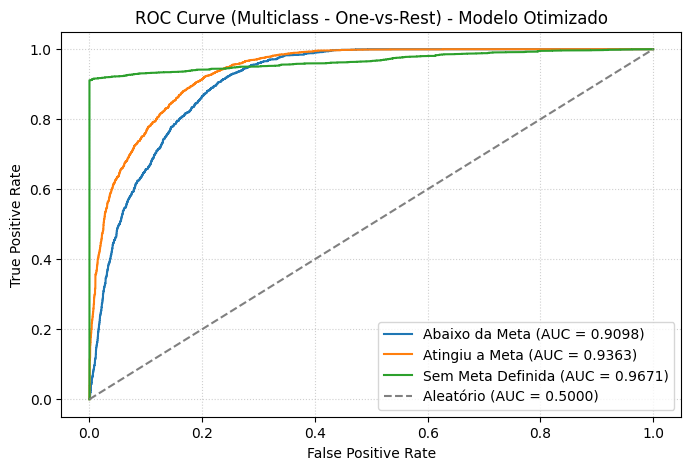

ROC AUC Score Geral (Weighted): 0.9406


In [81]:
# ===============================================================
# MÉTRICAS DE AVALIAÇÃO (MODELO OTIMIZADO RANDOMIZED SEARCH CV)
# ===============================================================

# Gerar predições e probabilidades usando o modelo otimizado pelo RandomizedSearchCV
predicao = random_search.predict(X_test_selected)
probabilidades = random_search.predict_proba(X_test_selected)

# 1. Métrica geral resumida (Média Ponderada)
accuracy = accuracy_score(y_test, predicao)
precision_weighted = precision_score(y_test, predicao, average='weighted')
recall_weighted = recall_score(y_test, predicao, average='weighted')
f1_weighted = f1_score(y_test, predicao, average='weighted')

print(f"Acurácia Geral:         {accuracy:.4f}")
print(f"Precisão (Weighted):    {precision_weighted:.4f}")
print(f"Recall (Weighted):      {recall_weighted:.4f}")
print(f"F1-Score (Weighted):    {f1_weighted:.4f}\n")

# 2. Visão detalhada por classe
print("--- Relatório Completo por Classe ---")
print(classification_report(y_test, predicao))

# 3. Matriz de Confusão
matriz = confusion_matrix(y_test, predicao)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot()
plt.show()

# 4. Curva ROC (Multiclass - One-vs-Rest)
# Binariza o y_test para permitir o cálculo classe por classe da curva ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Nomes amigáveis das classes obtidos do dataset
class_names = [str(c) for c in dados['status_meta'].astype('category').cat.categories]

# Cálculo do AUC Geral (Weighted)
auc_score_geral = roc_auc_score(y_test, probabilidades, multi_class='ovr', average='weighted')

# Plota a Curva ROC
plt.figure(figsize=(8, 5))

# Desenha uma linha para cada classe
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], probabilidades[:, i])
    auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i, label=f'{class_names[i]} (AUC = {auc_i:.4f})')

# Linha de referência (palpite aleatório)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (AUC = 0.5000)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass - One-vs-Rest) - Modelo Otimizado')

plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f'ROC AUC Score Geral (Weighted): {auc_score_geral:.4f}')

# **Validações e otimizações**

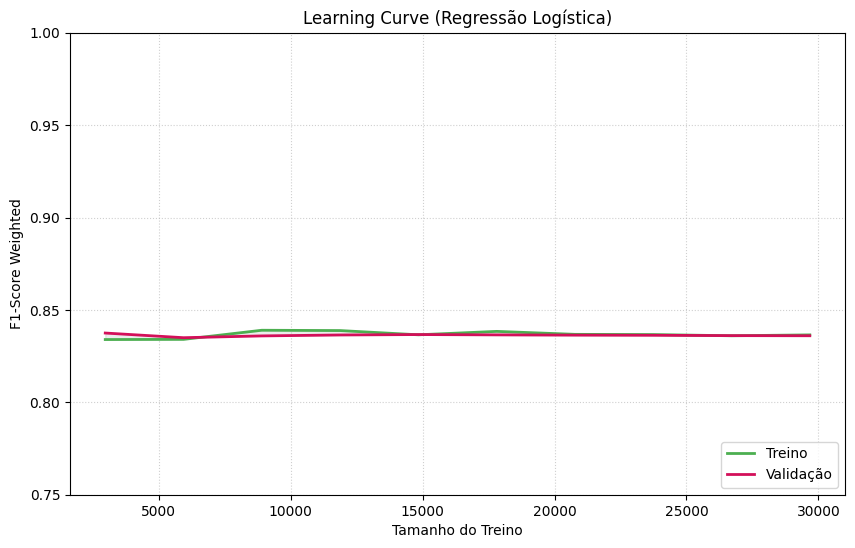

Diagnóstico Learning Curves: BOM AJUSTE
Ação sugerida: O modelo generaliza bem!
F1-Score na Validação: 0.8360
Gap Treino-Validação: 0.0005



In [82]:
##Learning Curves e Validation Curves

# 1. Learning Curves com a métrica (f1_weighted)
train_sizes, train_scores, val_scores = learning_curve(
    random_search.best_estimator_,
    X_train_selected,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

# 2. Média das métricas (sem o sinal de menos '-')
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# 3. Visualização da Curva de Aprendizado
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Treino', color='#4CAF50', lw=2)
plt.plot(train_sizes, val_mean, label='Validação', color='#D30F59', lw=2)
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.15, color='gray')

plt.xlabel('Tamanho do Treino')
plt.ylabel('F1-Score Weighted')
plt.title('Learning Curve (Regressão Logística)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0.75, 1.0)
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Diagnóstico Automático com Learning Curves
gap = train_mean[-1] - val_mean[-1]

if val_mean[-1] < 0.70 and gap < 0.05:
    diagnosis = 'UNDERFITTING'
    action = 'Aumente a complexidade das features (ex: PolynomialFeatures) ou diminua a regularização (aumente o C).'
elif gap > 0.10:
    diagnosis = 'OVERFITTING'
    action = 'Aumente a regularização (diminua o C), aplique seleção de features ou adicione mais dados.'
else:
    diagnosis = 'BOM AJUSTE'
    action = 'O modelo generaliza bem!'

print(f'Diagnóstico Learning Curves: {diagnosis}')
print(f'Ação sugerida: {action}')
print(f'F1-Score na Validação: {val_mean[-1]:.4f}')
print(f'Gap Treino-Validação: {gap:.4f}\n')

# #Validation Curves
# param_range = range(1, 21)
# tr_s, val_s = validation_curve(
#     RandomForestRegressor(n_estimators=50, random_state=42),
#     X_train_scaled, y_train,
#     param_name='max_depth', param_range=param_range,
#     cv=5, scoring='neg_mean_squared_error', n_jobs=-1
# )

# train_mean = -tr_s.mean(axis=1)
# val_mean = -val_s.mean(axis=1)
# best_depth = list(param_range)[np.argmin(val_mean)]

# plt.figure(figsize=(10, 6))
# plt.plot(param_range, train_mean, label='Treino',
#          color='#4CAF50')
# plt.plot(param_range, val_mean, label='Validação',
#          color='#D30F59')
# plt.axvline(best_depth, color='#FFD54F', linestyle='--',
#             label=f'Melhor max_depth={best_depth}')
# plt.xlabel('max_depth')
# plt.ylabel('Erro (MSE)')
# plt.legend()
# plt.title('Validation Curve')
# print(f'Melhor max_depth: {best_depth}')

# #Complexidade crescente (polinômios de grau 1 a 20)
# degrees = [1, 2, 3, 5, 10, 20]
# for deg in degrees:
#     model = Pipeline([
#         ('poly', PolynomialFeatures(deg)),
#         ('lin', LinearRegression())
#     ])
#     model.fit(X_train_scaled, y_train)
#     tr_err = mean_squared_error(y_train, model.predict(X_train_scaled))
#     te_err = mean_squared_error(y_test, model.predict(X_test_scaled))

#     status = ('UNDERFITTING' if tr_err > 0.5 and te_err > 0.5
#               else 'OVERFITTING' if te_err > tr_err * 2
#               else 'BOM AJUSTE')
#     print(f'Grau {deg:2d} | Treino={tr_err:.3f} | '
#           f'Teste={te_err:.3f} | {status}')



Summary Plot (Beeswarm) - Valores Originais


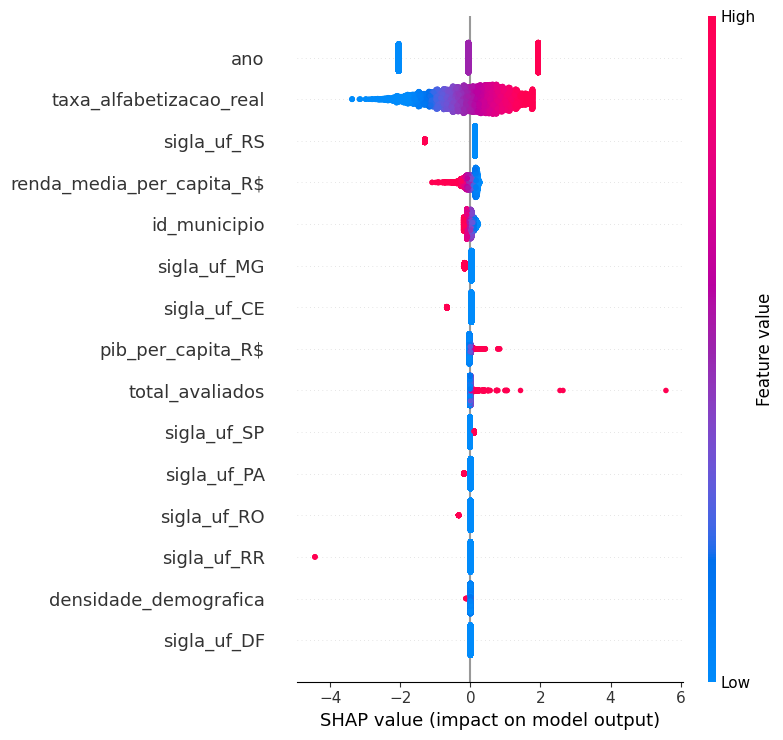

Summary Plot (Bar)


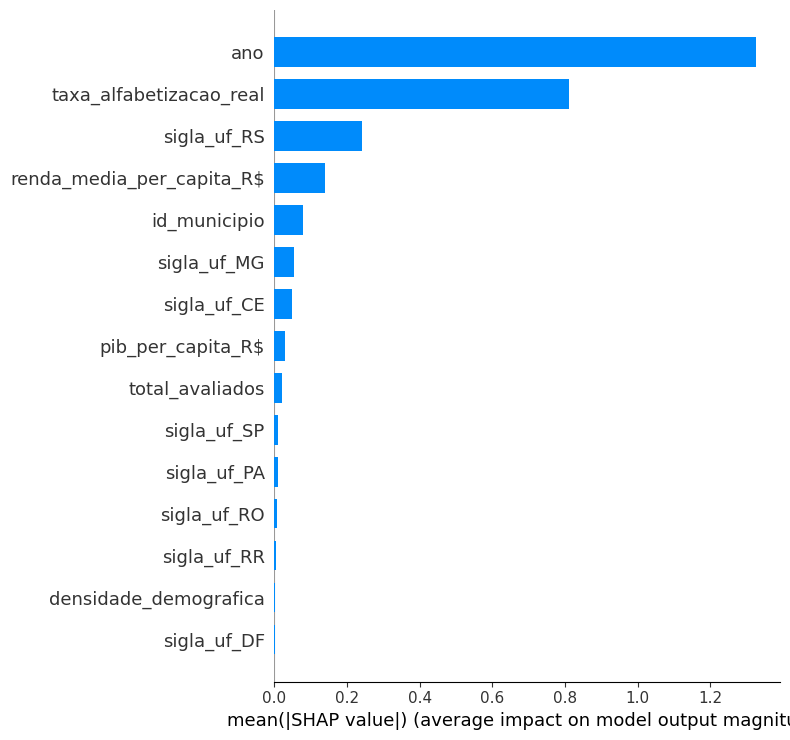

Dependence plots - Valores Originais


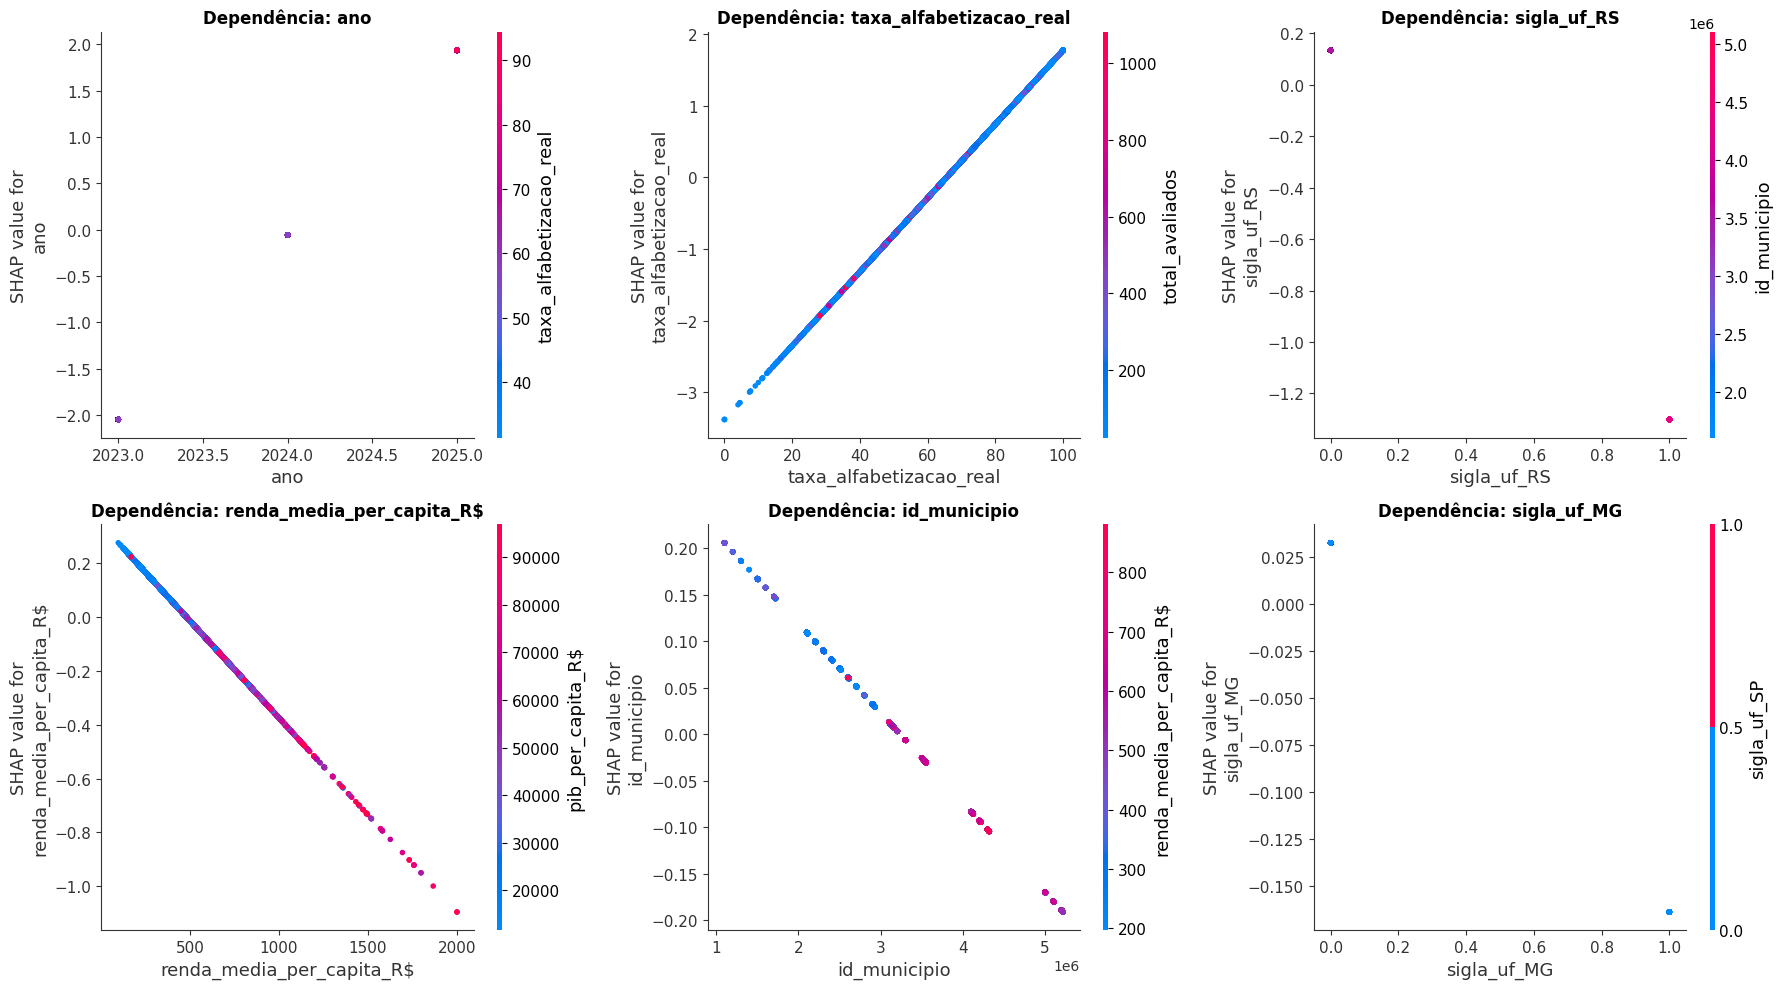

Waterfall plots - Valores Originais


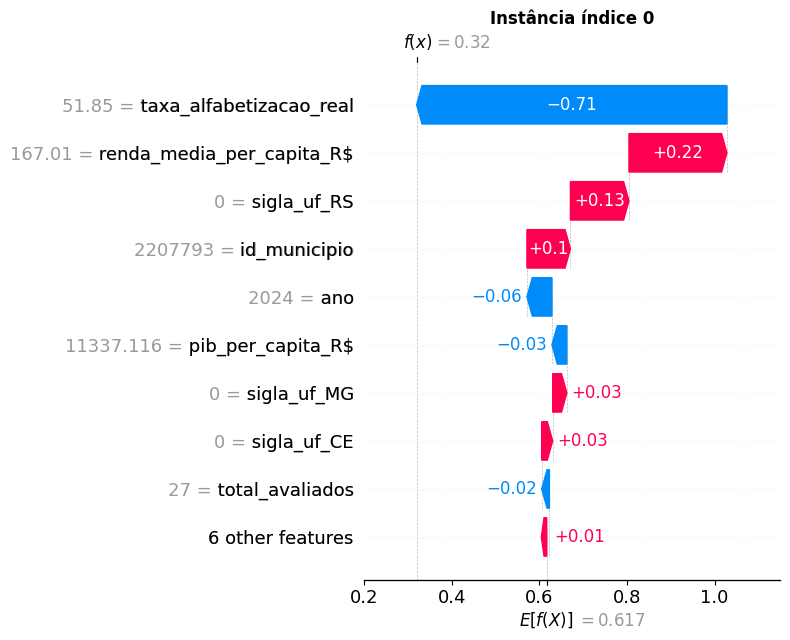

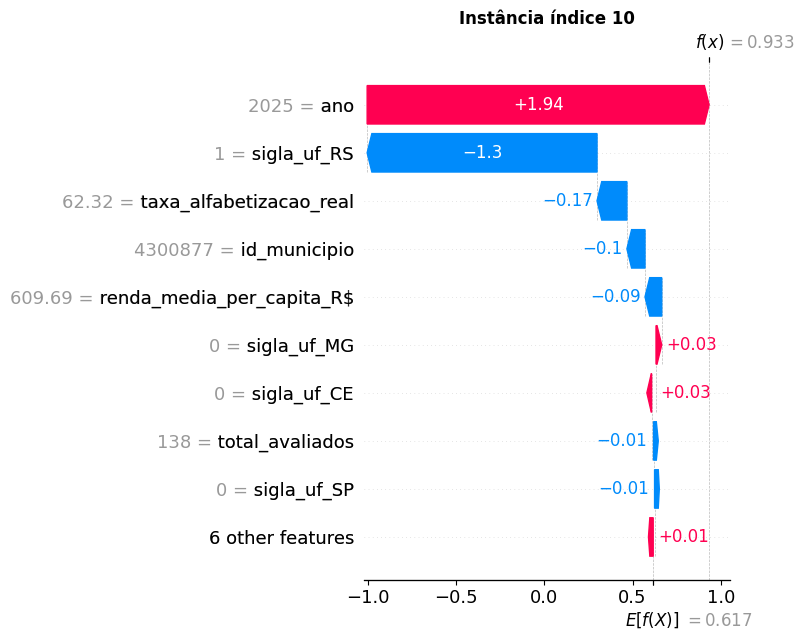

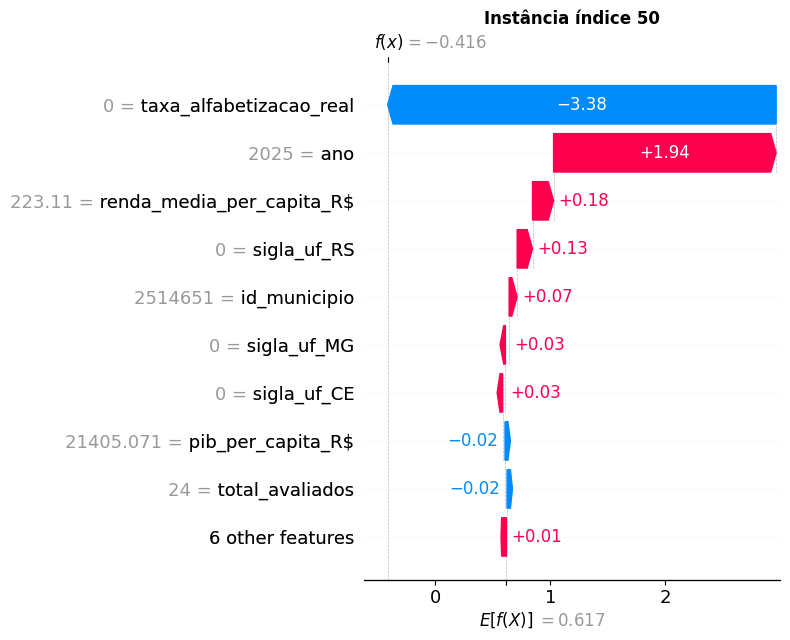

Decision plot


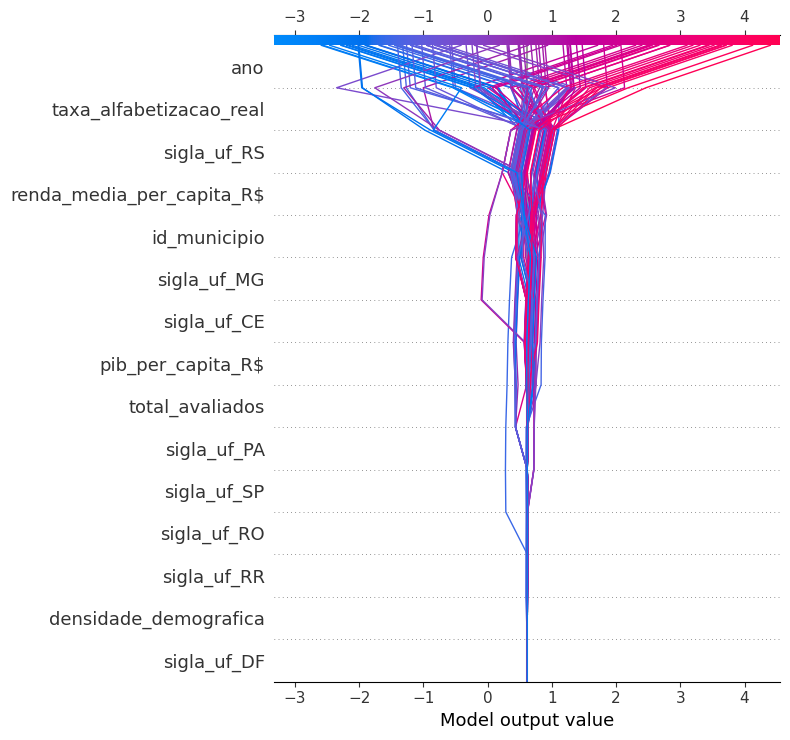

In [83]:
# ===============================================================
# SHAP PARA EXPLICABILIDADE
# ===============================================================

## Usando dataframe não escalonado para melhorar rótulos de waterfall plot
# 1. Nomes das 15 features selecionadas pelo SelectKBest
selected_cols = X.columns[selector.get_support()].tolist()

# 2. DataFrame ESCALONADO com as features selecionadas (usado pelo modelo)
X_train_scaled_df = pd.DataFrame(
    X_train_selected, columns=selected_cols, index=X_train.index
)
X_test_scaled_df = pd.DataFrame(
    X_test_selected, columns=selected_cols, index=X_test.index
)

# 3. DataFrame ORIGINAL (não-escalonado) apenas com as features selecionadas (usado para exibições no SHAP)
X_test_raw_df = X_test[selected_cols].copy()



##Criando visuais SHAP

# 4. Modelo final do treino
modelo_final = random_search.best_estimator_

# 5. Criar o explainer com os dados de treino escalonados
masker = shap.maskers.Independent(
    X_train_scaled_df, max_samples=len(X_train_scaled_df)
)
explainer = shap.LinearExplainer(modelo_final, masker)

# 6. Calcular a explicação baseada no teste ESCALONADO
explanation = explainer(X_test_scaled_df)

# Ajuste para pegar a classe positiva (índice 1) em classificação binária
if len(explanation.shape) == 3:
    explanation_classe = explanation[:, :, 1]
    shap_values_classe = explanation[:, :, 1].values
    expected_val = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )
else:
    explanation_classe = explanation
    shap_values_classe = explanation.values
    expected_val = explainer.expected_value


# ===============================================================
# 5. VISÃO GLOBAL (Summary Plot com valores originais)
# ===============================================================
print("Summary Plot (Beeswarm) - Valores Originais")
# Passando X_test_raw_df no argumento das cores, a barra exibe a escala real da variável
shap.summary_plot(explanation_classe, X_test_raw_df)

print("Summary Plot (Bar)")
shap.summary_plot(explanation_classe, X_test_raw_df, plot_type="bar")


# ===============================================================
# 6. DEPENDENCE PLOTS (Com eixos X exibindo valores originais)
# ===============================================================
print("Dependence plots - Valores Originais")

# Seleciona as Top 6 variáveis mais importantes
mean_abs_shap = np.abs(shap_values_classe).mean(axis=0)
top_features = (
    pd.Series(mean_abs_shap, index=selected_cols)
    .sort_values(ascending=False)
    .head(6)
    .index
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), top_features):
    # Passar X_test_raw_df faz o eixo X exibir os anos reais (ex: 2023, 2024, 2025)
    shap.dependence_plot(
        feat,
        shap_values_classe,
        X_test_raw_df,
        ax=ax,
        show=False,
    )
    ax.set_title(f"Dependência: {feat}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("dependence_grid_valores_reais.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# ===============================================================
# 7. WATERFALL PLOTS (Exibindo 2024, 59.66, etc., no eixo esquerdo)
# ===============================================================
print("Waterfall plots - Valores Originais")

for idx in [0, 10, 50]:
    # Construímos o Explanation manualmente combinando os SHAP values do modelo com os dados RAW
    exp_raw = shap.Explanation(
        values=explanation_classe[idx].values,
        base_values=explanation_classe[idx].base_values,
        data=X_test_raw_df.iloc[
            idx
        ].values,  # AQUI está o truque: exibe o valor real!
        feature_names=selected_cols,
    )

    plt.figure(figsize=(8, 6))
    shap.waterfall_plot(exp_raw, show=False)
    plt.title(f"Instância índice {idx}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"waterfall_idx_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


# ===============================================================
# 8. DECISION PLOT
# ===============================================================
print("Decision plot")
n_samples = min(100, len(X_test_raw_df))

plt.figure(figsize=(10, 6))
shap.decision_plot(
    expected_val,
    shap_values_classe[:n_samples],
    X_test_raw_df.iloc[:n_samples],  # Mostra rótulos/valores brutos nas linhas
    show=False,
)
plt.tight_layout()
plt.savefig("decision_plot.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()